# 01 - Data and Model Checks

This notebook prepares and inspects the original UK plate crop dataset, builds metadata, verifies `PlateDataset`/`DataLoader` behaviour, and runs lightweight baseline CNN smoke tests.

## Contents

1. Setup and reusable helpers
2. Raw dataset extraction
3. Metadata build and inspection
4. Dataset and DataLoader checks
5. Visual tensor checks
6. Baseline CNN smoke tests


## 1. Setup and Reusable Helpers


In [1]:
from pathlib import Path
import shutil
import sys

import matplotlib.pyplot as plt
import torch
from IPython.display import display
from torch.utils.data import DataLoader


PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


from anpr.data.dataset import PlateDataset
from anpr.data.encoders import decode_indices
from anpr.data.metadata import build_metadata_csv
from anpr.data.transforms import get_basic_transforms
from anpr.evaluation.metrics import calculate_plate_metrics, format_plate_metrics
from anpr.inference.decode import decode_model_outputs
from anpr.models.plate_cnn import PlateCNN, count_trainable_parameters
from anpr.training.losses import PlateMultiHeadLoss
from anpr.training.train_loop import evaluate_one_epoch, train_one_epoch


SOURCE_ROOT = PROJECT_ROOT / "data" / "raw" / "UKLicencePlateDataset"
PLATE_CROPS_DIR = PROJECT_ROOT / "data" / "raw" / "plate_crops"
METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates.csv"
INVALID_METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "invalid_plates.csv"

SOURCE_FOLDERS = {
    "whiteplate_normal": "white",
    "yellowplate_normal": "yellow",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMAGE_HEIGHT = 48
IMAGE_WIDTH = 160
PLATE_LENGTH = 7
BATCH_SIZE = 32
RANDOM_STATE = 42


In [2]:
def list_image_files(root: Path, extensions: set[str] = IMAGE_EXTENSIONS) -> list[Path]:
    return sorted(
        path
        for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in extensions
    )


def copy_original_plate_images(
    source_root: Path,
    dest_root: Path,
    folder_map: dict[str, str] = SOURCE_FOLDERS,
) -> int:
    total_copied = 0

    for source_folder_name, dest_folder_name in folder_map.items():
        source_folder = source_root / source_folder_name
        dest_folder = dest_root / dest_folder_name

        if not source_folder.exists():
            raise FileNotFoundError(f"Missing source folder: {source_folder}")

        dest_folder.mkdir(parents=True, exist_ok=True)
        image_files = list_image_files(source_folder)

        print(f"{source_folder_name}: found {len(image_files)} images")

        for image_path in image_files:
            destination_path = dest_folder / image_path.name

            if destination_path.exists():
                raise FileExistsError(
                    f"Duplicate filename found: {destination_path.name}. "
                    "Keep subfolders or add a safe renaming strategy."
                )

            shutil.copy2(image_path, destination_path)
            total_copied += 1

    print(f"Done. Copied {total_copied} original images into: {dest_root}")
    return total_copied


def build_plate_datasets(
    metadata_csv: Path = METADATA_CSV,
    project_root: Path = PROJECT_ROOT,
) -> tuple[PlateDataset, PlateDataset, PlateDataset]:
    transform = get_basic_transforms(
        image_height=IMAGE_HEIGHT,
        image_width=IMAGE_WIDTH,
    )

    def dataset_for(split: str) -> PlateDataset:
        return PlateDataset(
            metadata=metadata_csv,
            project_root=project_root,
            split=split,
            transform=transform,
            grayscale=True,
        )

    return dataset_for("train"), dataset_for("val"), dataset_for("test")


def make_loader(dataset: PlateDataset, shuffle: bool = True) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=0,
    )


def inspect_loader(name: str, loader: DataLoader) -> dict:
    batch = next(iter(loader))

    print(f"{name} image shape:", batch["image"].shape)
    print(f"{name} target shape:", batch["target"].shape)
    print(f"{name} first labels:", batch["label"][:5])

    return batch


def denormalise_plate_tensor(image_tensor: torch.Tensor):
    image = image_tensor.squeeze(0).detach().cpu().numpy()
    image = (image * 0.5) + 0.5
    return image.clip(0, 1)


def show_plate_sample(sample: dict) -> None:
    plt.figure(figsize=(8, 3))
    plt.imshow(denormalise_plate_tensor(sample["image"]), cmap="gray")
    plt.title(f"Label: {sample['label']}")
    plt.axis("off")
    plt.show()


def show_plate_batch(batch: dict, num_images: int = 16) -> None:
    images = batch["image"]
    targets = batch["target"]
    labels = batch["label"]

    rows = 4
    cols = 4
    num_images = min(num_images, rows * cols, len(images))

    plt.figure(figsize=(14, 7), dpi=90)

    for index in range(num_images):
        plt.subplot(rows, cols, index + 1)
        image = denormalise_plate_tensor(images[index])
        decoded = decode_indices(targets[index].tolist())

        plt.imshow(image, cmap="gray")
        plt.title(f"{labels[index]} | {decoded}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


## 2. Raw Dataset Extraction


### 2.1 Copy Original Plate Images


In [3]:
copy_original_plate_images(SOURCE_ROOT, PLATE_CROPS_DIR)


whiteplate_normal: found 12000 images
yellowplate_normal: found 12000 images
Done. Copied 24000 original images into: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops


24000

### 2.2 Verify Copied Images


In [4]:
all_images = list_image_files(PLATE_CROPS_DIR)

print("Total clean original images:", len(all_images))
print("First 10 images:")

for image_path in all_images[:10]:
    print(image_path.relative_to(PLATE_CROPS_DIR))


Total clean original images: 24000
First 10 images:
white\AA03BOJ.png
white\AA06OHE.png
white\AA15VJJ.png
white\AA19HSV.png
white\AA22JTE.png
white\AA25WEI.png
white\AA39HMS.png
white\AA61PSS.png
white\AA67AAL.png
white\AA70PYY.png


## 3. Metadata Build and Inspection


### 3.1 Build Metadata CSV


In [5]:
df = build_metadata_csv(
    image_dir=PLATE_CROPS_DIR,
    output_csv=METADATA_CSV,
    invalid_csv=INVALID_METADATA_CSV,
    project_root=PROJECT_ROOT,
    source_name="uk_plate_original_crops",
    allow_embedded_plate=False,
    random_state=RANDOM_STATE,
)

display(df.head())


,image_id,image_path,label,label_length,source,split
0,AA03BOJ,data/raw/plate_crops/white/AA03BOJ.png,AA03BOJ,7,uk_plate_original_crops,train
1,AA06OHE,data/raw/plate_crops/white/AA06OHE.png,AA06OHE,7,uk_plate_original_crops,train
2,AA15VJJ,data/raw/plate_crops/white/AA15VJJ.png,AA15VJJ,7,uk_plate_original_crops,train
3,AA19HSV,data/raw/plate_crops/white/AA19HSV.png,AA19HSV,7,uk_plate_original_crops,train
4,AA22JTE,data/raw/plate_crops/white/AA22JTE.png,AA22JTE,7,uk_plate_original_crops,train


### 3.2 Inspect Metadata


In [6]:
print("Shape:", df.shape)

print("\nSplit counts:")
display(df["split"].value_counts())

print("\nLabel length counts:")
display(df["label"].str.len().value_counts())

print("\nPreview:")
display(df.head())


Shape: (24000, 6)

Split counts:


split
train    19200
test      2400
val       2400
Name: count, dtype: int64


Label length counts:


label
7    24000
Name: count, dtype: int64


Preview:


,image_id,image_path,label,label_length,source,split
0,AA03BOJ,data/raw/plate_crops/white/AA03BOJ.png,AA03BOJ,7,uk_plate_original_crops,train
1,AA06OHE,data/raw/plate_crops/white/AA06OHE.png,AA06OHE,7,uk_plate_original_crops,train
2,AA15VJJ,data/raw/plate_crops/white/AA15VJJ.png,AA15VJJ,7,uk_plate_original_crops,train
3,AA19HSV,data/raw/plate_crops/white/AA19HSV.png,AA19HSV,7,uk_plate_original_crops,train
4,AA22JTE,data/raw/plate_crops/white/AA22JTE.png,AA22JTE,7,uk_plate_original_crops,train


## 4. Dataset and DataLoader Checks


### 4.1 Build Datasets


In [7]:
train_ds, val_ds, test_ds = build_plate_datasets()

print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))


Train size: 19200
Validation size: 2400
Test size: 2400


### 4.2 Inspect One Sample


In [8]:
sample = train_ds[0]
image = sample["image"]
target = sample["target"]
label = sample["label"]

print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Image min:", image.min().item())
print("Image max:", image.max().item())
print("Image mean:", image.mean().item())
print("Target:", target.tolist())
print("Decoded target:", decode_indices(target.tolist()))
print("Original label:", label)
print("Image path:", sample["image_path"])

assert image.shape == (1, IMAGE_HEIGHT, IMAGE_WIDTH)
assert target.shape == (PLATE_LENGTH,)
assert decode_indices(target.tolist()) == label


Image shape: torch.Size([1, 48, 160])
Image dtype: torch.float32
Image min: -1.0
Image max: 0.9843137860298157
Image mean: 0.2363511472940445
Target: [0, 0, 0, 3, 1, 14, 9]
Decoded target: AA03BOJ
Original label: AA03BOJ
Image path: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops\white\AA03BOJ.png


### 4.3 Build and Inspect DataLoaders


In [9]:
train_loader = make_loader(train_ds)
val_loader = make_loader(val_ds)
test_loader = make_loader(test_ds)

train_batch = inspect_loader("Train", train_loader)
print()
val_batch = inspect_loader("Validation", val_loader)
print()
test_batch = inspect_loader("Test", test_loader)


Train image shape: torch.Size([32, 1, 48, 160])
Train target shape: torch.Size([32, 7])
Train first labels: ['SB98XKV', 'KF01BAW', 'RU15LLJ', 'XS01XHT', 'AP90IJW']

Validation image shape: torch.Size([32, 1, 48, 160])
Validation target shape: torch.Size([32, 7])
Validation first labels: ['HL38GXS', 'DI33XBA', 'EO67XGF', 'PU55ODP', 'CI07ZWA']

Test image shape: torch.Size([32, 1, 48, 160])
Test target shape: torch.Size([32, 7])
Test first labels: ['SO79JFA', 'BA80GDN', 'DQ93HEP', 'NV31VVB', 'HQ98VQH']


### 4.4 DataLoader Sanity Assertions


In [10]:
batch = next(iter(train_loader))

assert batch["image"].ndim == 4
assert batch["target"].ndim == 2
assert batch["image"].shape[1:] == (1, IMAGE_HEIGHT, IMAGE_WIDTH)
assert batch["target"].shape[1] == PLATE_LENGTH

print("Batch image shape:", batch["image"].shape)
print("Batch target shape:", batch["target"].shape)
print("Image value range:", batch["image"].min().item(), batch["image"].max().item())
print("First 5 labels:", batch["label"][:5])


Batch image shape: torch.Size([32, 1, 48, 160])
Batch target shape: torch.Size([32, 7])
Image value range: -1.0 0.9843137860298157
First 5 labels: ['SR25TJU', 'PE97EZF', 'HL16SOW', 'LJ98VDI', 'VC82XBO']


## 5. Visual Tensor Checks


### 5.1 Display One Plate Tensor


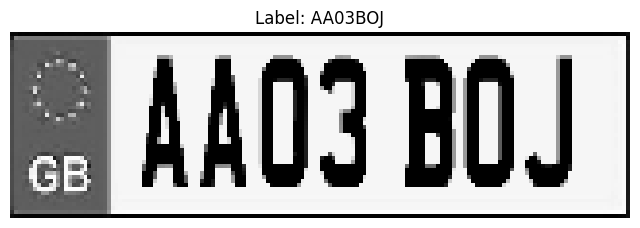

In [11]:
show_plate_sample(train_ds[0])


### 5.2 Display a Batch of Plate Tensors


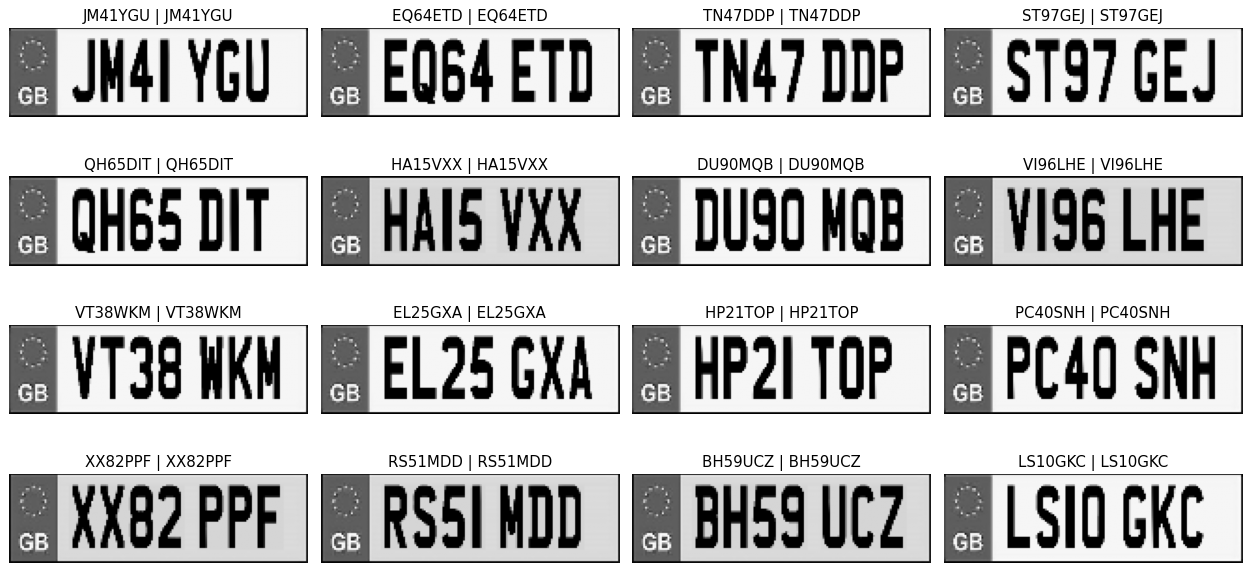

In [12]:
show_plate_batch(next(iter(train_loader)))


## 6. Baseline CNN Smoke Tests


### 6.1 Load CNN


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlateCNN(in_channels=1).to(device)

print(model)
print("Trainable parameters:", count_trainable_parameters(model))


PlateCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
    )
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2

### 6.2 Forward Pass on One Batch


In [14]:
batch = next(iter(train_loader))
images = batch["image"].to(device)
targets = batch["target"].to(device)

outputs = model(images)

print("Number of heads:", len(outputs))

for position, output in enumerate(outputs):
    print(f"Position {position}: output shape = {output.shape}")

print("Target shape:", targets.shape)


Number of heads: 7
Position 0: output shape = torch.Size([32, 26])
Position 1: output shape = torch.Size([32, 26])
Position 2: output shape = torch.Size([32, 10])
Position 3: output shape = torch.Size([32, 10])
Position 4: output shape = torch.Size([32, 26])
Position 5: output shape = torch.Size([32, 26])
Position 6: output shape = torch.Size([32, 26])
Target shape: torch.Size([32, 7])


### 6.3 Loss Smoke Test


In [15]:
model = PlateCNN(in_channels=1).to(device)
loss_fn = PlateMultiHeadLoss()

batch = next(iter(train_loader))
images = batch["image"].to(device)
targets = batch["target"].to(device)

outputs = model(images)
total_loss, position_losses = loss_fn(outputs, targets)

print("Total loss:", total_loss.item())

for position, position_loss in enumerate(position_losses):
    print(f"Position {position} loss:", position_loss.item())


Total loss: 3.0212769508361816
Position 0 loss: 3.308444023132324
Position 1 loss: 3.2560694217681885
Position 2 loss: 2.3254241943359375
Position 3 loss: 2.3826651573181152
Position 4 loss: 3.3177597522735596
Position 5 loss: 3.316816568374634
Position 6 loss: 3.2417593002319336


### 6.4 Prediction Format Check


In [16]:
model.eval()

batch = next(iter(train_loader))
images = batch["image"].to(device)
labels = batch["label"]

with torch.no_grad():
    outputs = model(images)

predictions = decode_model_outputs(outputs)

for index in range(10):
    print(
        "True:",
        labels[index],
        "| Pred:",
        predictions[index].cleaned_prediction,
        "| Valid:",
        predictions[index].is_valid_format,
        "| Confidence:",
        round(predictions[index].overall_confidence, 4),
    )


True: LT38XLH | Pred: SQ52VHR | Valid: True | Confidence: 0.0576
True: PZ68ATV | Pred: SQ22VHR | Valid: True | Confidence: 0.0577
True: CK22WLI | Pred: CQ22VHR | Valid: True | Confidence: 0.0577
True: JQ34ZUZ | Pred: SQ22VVR | Valid: True | Confidence: 0.0577
True: SL24RCT | Pred: SQ02VVR | Valid: True | Confidence: 0.0577
True: EC72ODR | Pred: SQ22DVR | Valid: True | Confidence: 0.0576
True: TQ93KCW | Pred: CQ52VVR | Valid: True | Confidence: 0.0577
True: HM43KDQ | Pred: CQ22VVR | Valid: True | Confidence: 0.0577
True: ZW03ESD | Pred: CQ22VHR | Valid: True | Confidence: 0.0577
True: UO62XMB | Pred: SQ22VHR | Valid: True | Confidence: 0.0578


### 6.5 Metrics Check


In [17]:
model.eval()

batch = next(iter(val_loader))
images = batch["image"].to(device)
labels = list(batch["label"])

with torch.no_grad():
    outputs = model(images)

predictions = decode_model_outputs(outputs)
metrics = calculate_plate_metrics(predictions, labels)

print(format_plate_metrics(metrics))


Samples: 32
Full-plate accuracy: 0.0000
Regex-valid rate: 1.0000
Average confidence: 0.0577
Per-position accuracy:
  Position 0: 0.0938
  Position 1: 0.0938
  Position 2: 0.1562
  Position 3: 0.1250
  Position 4: 0.0625
  Position 5: 0.0312
  Position 6: 0.0312


### 6.6 Training Loop Smoke Test


In [18]:
model = PlateCNN(in_channels=1).to(device)
loss_fn = PlateMultiHeadLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_result = train_one_epoch(
    model=model,
    dataloader=train_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device,
    max_batches=5,
)

val_result = evaluate_one_epoch(
    model=model,
    dataloader=val_loader,
    loss_fn=loss_fn,
    device=device,
    max_batches=5,
)

print("Train loss:", train_result.loss)
print("Train position losses:", train_result.position_losses)
print("Val loss:", val_result.loss)
print("Val position losses:", val_result.position_losses)
print(format_plate_metrics(val_result.metrics))


Training:   0%|          | 0/600 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/75 [00:00<?, ?it/s]

Train loss: 3.268147087097168
Train position losses: [3.492732381820679, 3.4805670738220216, 2.548983335494995, 2.3745214462280275, 3.593393898010254, 3.7078020572662354, 3.679028558731079]
Val loss: 3.0000661849975585
Val position losses: [3.288144111633301, 3.2773624420166017, 2.3032052993774412, 2.3192323207855225, 3.2648812770843505, 3.2806139945983888, 3.2670231819152833]
Samples: 160
Full-plate accuracy: 0.0000
Regex-valid rate: 1.0000
Average confidence: 0.0743
Per-position accuracy:
  Position 0: 0.0437
  Position 1: 0.0625
  Position 2: 0.1187
  Position 3: 0.0750
  Position 4: 0.0688
  Position 5: 0.0187
  Position 6: 0.0187
